# SMEFT scan workbench (W±HH, ZHH)

Load `*_SMEFT_Summary.txt` files, **interpolate** σ\_NNLO and K (with uncertainties) at any Wilson coefficient inside the tabulated range, and produce publication **two-panel plots** (σ\_NNLO + K).

Operator folders use canonical names without a leading `c` (`phiq3st`, not `cphiq3st`).

In [31]:
from pathlib import Path
import importlib
import sys

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'Package'))
sys.path.insert(0, str(ROOT / 'analysis_tools'))

import vhh_predict.plots as vpp
import smeft_scan_tools as sst
import plot_smeft_summaries as pss

# Reload plotting modules so notebook picks up API changes (inset_loc, legend_scale, ...)
importlib.reload(vpp)
importlib.reload(sst)
importlib.reload(pss)

SMEFT_ROOT = ROOT / 'SMEFT_Results'

## Configuration

In [249]:
PROCESS = "ZHH"   # WplusHH | WminusHH | ZHH
ENERGY_TAG = '14_0TeV' # 13_6TeV | 14_0TeV
OPERATOR = "phiW"      # phi | phiW | phiD | phiBox | phiq3st | Phi | phiB | phiWB | phiq3rd | phit

# Plot / interpolation window (must lie inside tabulated wc range)
WC_LO = -0.4
WC_HI = 1

# Wilson coefficients to interpolate and print
QUERY_WC = [0.0]

# Data / curve options
SMOOTH_PLOT = True     # None = auto (smooth for phiq3st); True/False to override
SIGMA_INSET = True     # True = force zoom inset; False = never; None = auto (phiBox/phiq3st)
SHOW_K_NLO = False       # overlay K_NLO on lower panel (requires rebuilt summaries)
INTERP_DEGREE = 3     # 1=linear, 2=quadratic (default), 3=cubic (needs >=4 points)
INSET_XLIM = None   # manual wc window for inset; None = auto from INSET_X_FRACTION

# --- Plot typography (points) ---
AXIS_LABEL_FONTSIZE = 18
TICK_LABEL_FONTSIZE = 16
LEGEND_FONTSIZE = 14
TITLE_FONTSIZE = 18

# --- Figure geometry ---
FIGSIZE = (8.0, 7.0)
PANEL_HEIGHT_RATIOS = (2.6, 1.0)
LINE_WIDTH = 2.2
SAVE_DPI = 300
LEGEND_FRAMEALPHA = 0.92

# --- Layout / inset ---
INSET_SCALE = 2.0        # inset box size relative to legend (default 1.5)
INSET_X_FRACTION = 0.00001  # auto inset wc window = fraction of plot x-span
TITLE_Y = 1.02            # suptitle y (larger → higher)
TITLE_LAYOUT_TOP = 0.97   # top of subplot area (smaller → more gap under title)
X_PAD_FRAC = 0.04         # x-axis margin on both sides of wc window

# Legend / inset corners: horizontal left|right, vertical upper|lower
LEGEND_H, LEGEND_V = "right", "lower"
INSET_H, INSET_V = "left", "upper"   # set inset_h=None in PLOT_STYLE to hide inset box

# Bundle all plot styling (edit numbers above, or override fields here)
PLOT_STYLE = pss.SmeftPlotStyle(
    axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    tick_label_fontsize=TICK_LABEL_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
    title_fontsize=TITLE_FONTSIZE,
    title_y=TITLE_Y,
    title_layout_top=TITLE_LAYOUT_TOP,
    x_pad_frac=X_PAD_FRAC,
    inset_x_fraction=INSET_X_FRACTION,
    inset_scale=INSET_SCALE,
    legend_h=LEGEND_H,
    legend_v=LEGEND_V,
    inset_h=INSET_H,
    inset_v=INSET_V,
    legend_framealpha=LEGEND_FRAMEALPHA,
    line_width=LINE_WIDTH,
    figsize=FIGSIZE,
    height_ratios=PANEL_HEIGHT_RATIOS,
    save_dpi=SAVE_DPI,
)

# Trailing comma required for a one-element tuple: ('png',) not ('png')
PLOT_FORMATS = ('png',)

## Load summary

In [250]:
summary_path = sst.smeft_summary_path(SMEFT_ROOT, PROCESS, ENERGY_TAG, OPERATOR)
meta, scan = pss.parse_smeft_summary(summary_path)
meta['wc_subdir'] = sst.canonical_scan_subdir(meta['wc_subdir'])

wc_min, wc_max = sst.scan_wc_bounds(scan)
print(f'Summary: {summary_path.name}')
print(f'Operator: {meta["wc_subdir"]}  |  Wilson coeff key: {meta["wc"]}')
print(f'Tabulated wc range: [{wc_min:g}, {wc_max:g}]  ({len(scan["wc"])} points)')
print(f'Requested window:   [{WC_LO:g}, {WC_HI:g}]')

if WC_LO < wc_min or WC_HI > wc_max:
    raise ValueError('Plot window exceeds tabulated scan range')

Summary: ZHH_14_0TeV_phiW_SMEFT_Summary.txt
Operator: phiW  |  Wilson coeff key: cHw
Tabulated wc range: [-0.4, 1]  (8 points)
Requested window:   [-0.4, 1]


## Interpolate and print

In [251]:
for wc in QUERY_WC:
    if wc < WC_LO or wc > WC_HI:
        print(f'skip wc={wc:g} (outside [{WC_LO:g}, {WC_HI:g}])')
        continue
    pred = sst.predict_at_wc(scan, wc, wc_lo=WC_LO, wc_hi=WC_HI, degree=INTERP_DEGREE)
    print(sst.format_prediction(wc, pred))
    print()

wc = 0
  sigma_NNLO = 0.417271 fb  (+/- PDF+as 0.00787257, scale -0.0112227 / +0.0142857)
  K_NNLO     = 1.36411  (+/- PDF+as 0.00539918, scale -0.0287861 / +0.0343024)
  K_NLO      = 1.17698



## Two-panel plot (σ\_NNLO + K)

Saved:
  /Users/michalryczkowski/Documents/Projects/Current/Gioia/Code_21_04/pphhV/SMEFT_Results/ZHH/14_0TeV/full/phiW/ZHH_14_0TeV_phiW_SMEFT_plot_-0.4_to_1.png


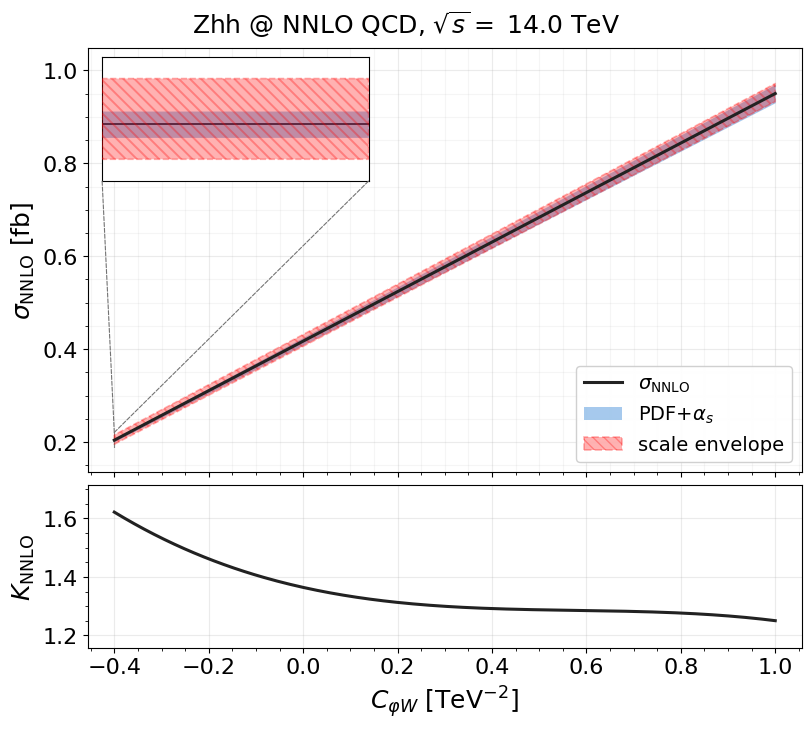

In [252]:
op = sst.canonical_scan_subdir(OPERATOR)
plot_stem = (
    SMEFT_ROOT / PROCESS / ENERGY_TAG / 'full' / op
    / f'{PROCESS}_{ENERGY_TAG}_{op}_SMEFT_plot_{WC_LO:g}_to_{WC_HI:g}'
)

# One figure for display and file export (identical pixels)
fig = pss.make_bounded_plot_figure(
    meta,
    scan,
    wc_lo=WC_LO,
    wc_hi=WC_HI,
    sigma_inset=SIGMA_INSET,
    smooth=SMOOTH_PLOT,
    interp_degree=INTERP_DEGREE,
    inset_xlim=INSET_XLIM,
    show_k_nlo=SHOW_K_NLO,
    style=PLOT_STYLE,
)
written = pss.save_plot_figure(fig, plot_stem, formats=PLOT_FORMATS, style=PLOT_STYLE)
print('Saved:')
for p in written:
    print(' ', p.resolve())
plt.show()